In [13]:
import h5py
import numpy as np
from src.lcgen.utils.trunc_data import trunc_data
import matplotlib.pyplot as plt


In [2]:
new = trunc_data('data/timeseries.h5', keys=['flux','flux_err','time'], max_length=512)

In [ ]:

with h5py.File('data/timeseries.h5', 'r') as hf:
    for key in hf.keys():
        data = hf[key][:]
        data_trunc = hf[key][:len]
        new_hf[key] = data_trunc
    print(list(hf.keys()))
    print(len(hf['length']))
    print(hf['flux'].shape)



AttributeError: 'File' object has no attribute 'shape'

In [5]:
time = [0,1,2.3,3,3.5,5,6.3,7,7.7,7.8,9,10]

In [6]:
t_range_i = np.max(time) - np.min(time)
phase = np.random.uniform(0, 2 * np.pi)
amp = np.random.normal(1, 0.5)  # Random amplitude
num_cycles = np.abs(np.random.normal(3, 2))  # Random number of cycles
period = t_range_i / num_cycles


In [15]:
num_cycles

1.1584683966625329

In [10]:
t_reg_space = np.linspace(0, t_range_i, len(time))


In [11]:
t_reg_space

array([ 0.        ,  0.90909091,  1.81818182,  2.72727273,  3.63636364,
        4.54545455,  5.45454545,  6.36363636,  7.27272727,  8.18181818,
        9.09090909, 10.        ])

In [12]:
flux_reg_space = amp * np.sin(t_reg_space * (2 * np.pi / period) + phase)


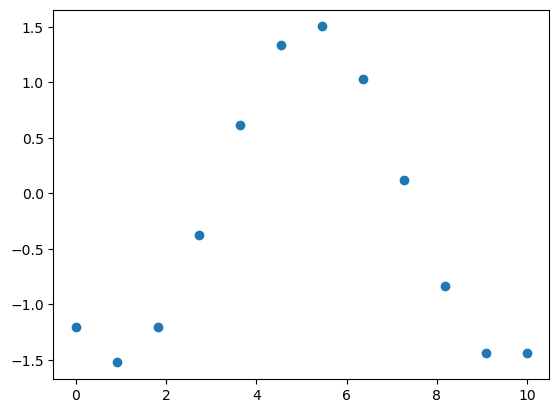

In [14]:
plt.scatter(t_reg_space, flux_reg_space, label='Interpolated Flux')

In [17]:
flux_at_t = np.interp(time, t_reg_space, flux_reg_space)

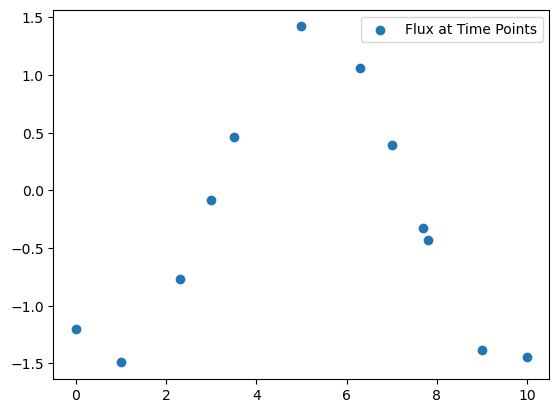

In [18]:
plt.scatter(time, flux_at_t, label='Flux at Time Points')
plt.legend()
plt.show()